In [ ]:
# --- Libraries ---
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


import os 

# --- Configuration ---
os.chdir(r"C:\Users\Alejandro\Documents\Msc Analisis Economico Cuantitativo UAM\TFM\data")

## Serie: Numero de turistas por pais de residencia

https://ine.es/jaxiT3/Tabla.htm?t=10822

La serie de turismo no es estacionaria, para convertirla a estacionaria hace falta una diferencia regular y una diferencia estacional (s = 12).

In [ ]:
turismo_residencia = pd.read_csv("turismo_pais_residencia.csv", sep="\t")

# Set the index to monthly_gpr for easier comparison
turismo_residencia.set_index("Periodo", inplace=True)
turismo_residencia.index = pd.to_datetime(turismo_residencia.index, format="%YM%m")

# Set the number as so
turismo_residencia["Total"] = pd.to_numeric(
    turismo_residencia["Total"].astype(str)
        .str.replace(".", "", regex=False)    
        .str.replace(",", ".", regex=False),  
    errors="coerce"
).astype("float64")  

# Filter for all tourists (Total) and base data only
turismo_residencia= turismo_residencia[
    (turismo_residencia["Tipo de dato"] == "Dato base")&
    (turismo_residencia["País de residencia"] == "Total")]

# Drop the now redundant columns
turismo_residencia.drop(columns=["Tipo de dato", "País de residencia"], inplace=True)
turismo_residencia = turismo_residencia.sort_index()

ADF Test P-value on the series in level: 0.17858121132558402


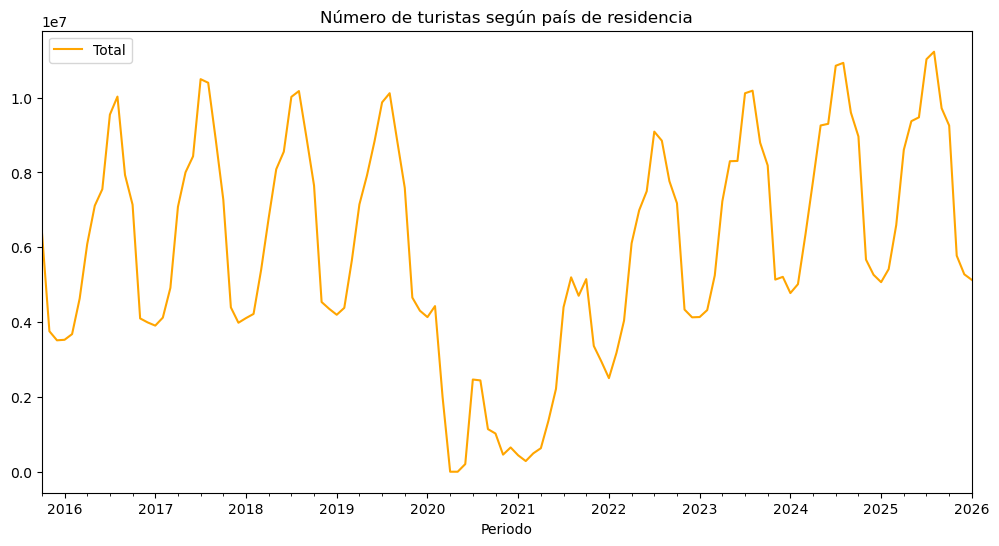

In [ ]:
# ADF and plotting of the data
turismo_residencia.plot(figsize=(12,6), title="Número de turistas según país de residencia", color="orange")
adfuller_turismo = adfuller(turismo_residencia["Total"].dropna())
print("ADF Test P-value on the series in level:", adfuller_turismo[1])

ADF Test P-value on the series with seasonal difference: 0.009664943770957916


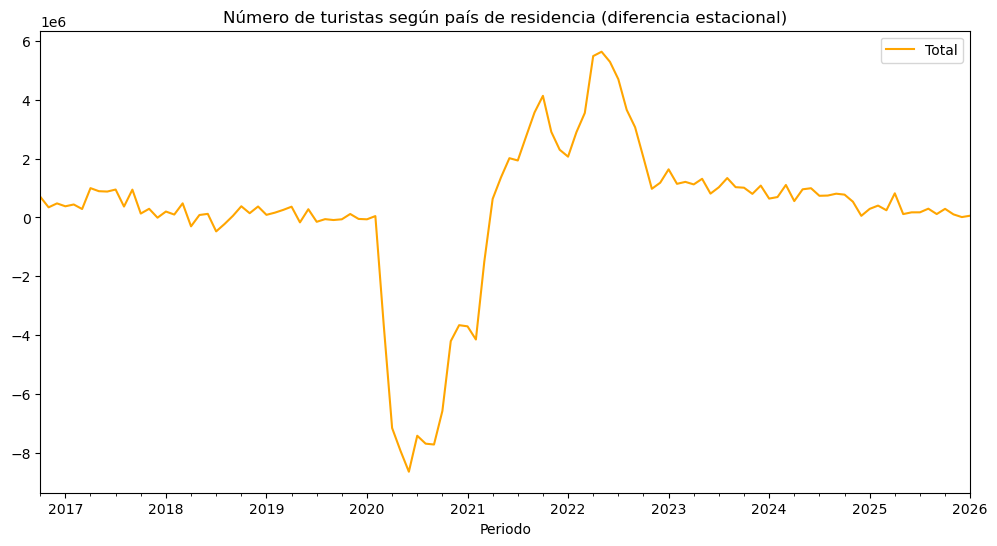

In [ ]:
# Seasonal difference and ADF test
s = 12 # Orden de la diferencia estacional
turismo_residencia_12d = turismo_residencia.diff(s).dropna()

turismo_residencia_12d.plot(figsize=(12,6), title="Número de turistas según país de residencia (diferencia estacional)", color="orange")
adfuller_turismo_12d = adfuller(turismo_residencia_12d["Total"], regression="n")
print("ADF Test P-value on the series with seasonal difference:", adfuller_turismo_12d[1])


ADF Test P-value on the series with seasonal difference: 0.0004780348618973809


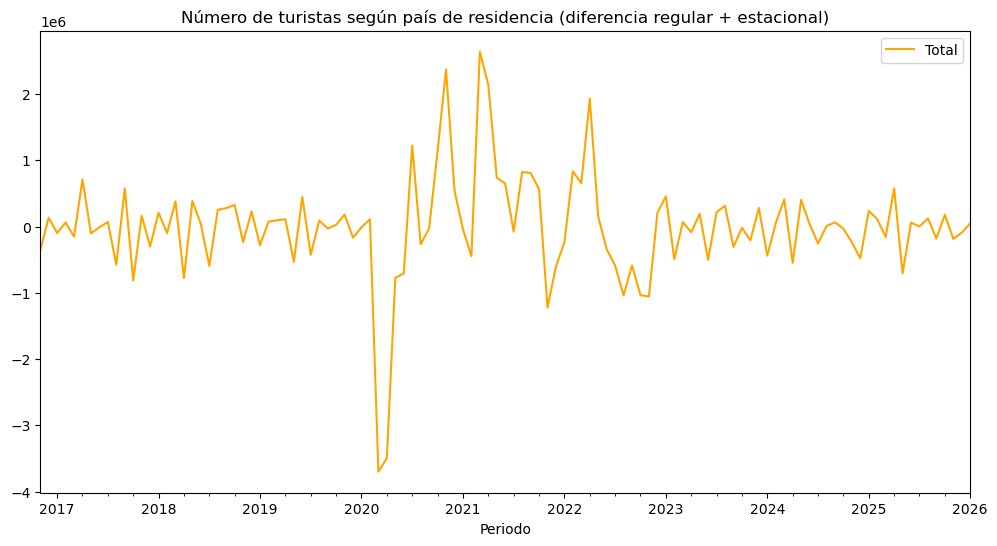

In [ ]:
turismo_residencia_12d_d = turismo_residencia.diff().diff(s).dropna()

turismo_residencia_12d_d.plot(figsize=(12,6), title="Número de turistas según país de residencia (diferencia regular + estacional)", color="orange")
adfuller_turismo_12d_d = adfuller(turismo_residencia_12d_d["Total"], regression="n") # Deberia usar constante en este??
print("ADF Test P-value on the series with seasonal difference:", adfuller_turismo_12d_d[1])


## Serie: Tourism Revenue

C:\Users\Alejandro\AppData\Local\Temp\ipykernel_5752\1938552504.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  turism_revenue["Fecha"] = pd.to_datetime(turism_revenue["Fecha"])


<Axes: xlabel='Fecha'>

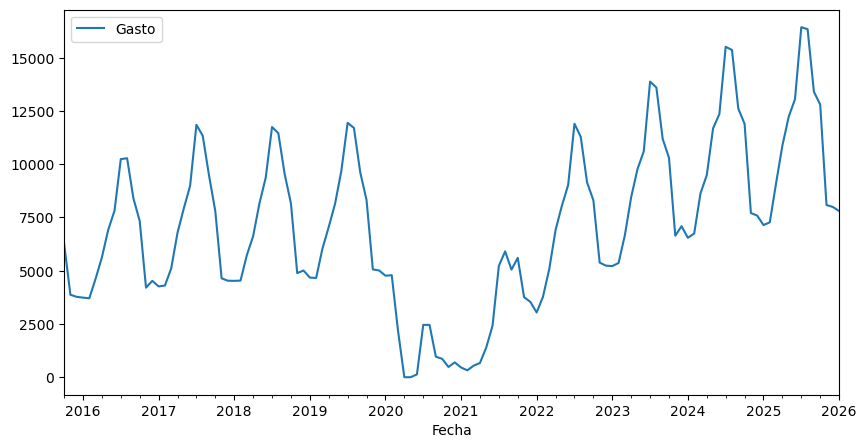

In [ ]:
turism_revenue = pd.read_excel(r"C:\Users\Alejandro\Documents\Msc Analisis Economico Cuantitativo UAM\TFM\data\gasto_total_turistas.xlsx")

# Correct date format

turism_revenue["Fecha"] = turism_revenue["Fecha"].str.replace("M","-")
turism_revenue["Fecha"] = pd.to_datetime(turism_revenue["Fecha"])

turism_revenue.set_index(turism_revenue["Fecha"], inplace=True)
turism_revenue.drop(columns = ["Fecha"], inplace = True)

# Truning gasto into a numnber
turism_revenue["Gasto"] = pd.to_numeric(turism_revenue["Gasto"], errors='coerce')
turism_revenue = turism_revenue.sort_index()

turism_revenue.plot(figsize=(10, 5))

## Serie: High Frequency Tourism Indicator

<Axes: title={'center': '1st Common Factor (Kalman Filter)'}, xlabel='Time'>

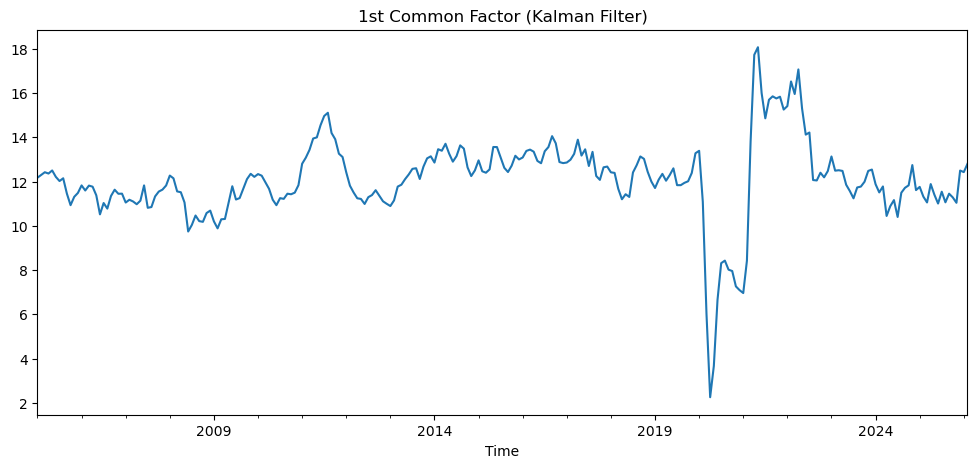

In [ ]:
hfti = pd.read_csv("turism_hf_indicator.csv", index_col=0)
hfti.index = pd.to_datetime(hfti.index)
hfti["Factor_1_KSmoother"].plot(figsize=(12,5), title="1st Common Factor (Kalman Filter)")

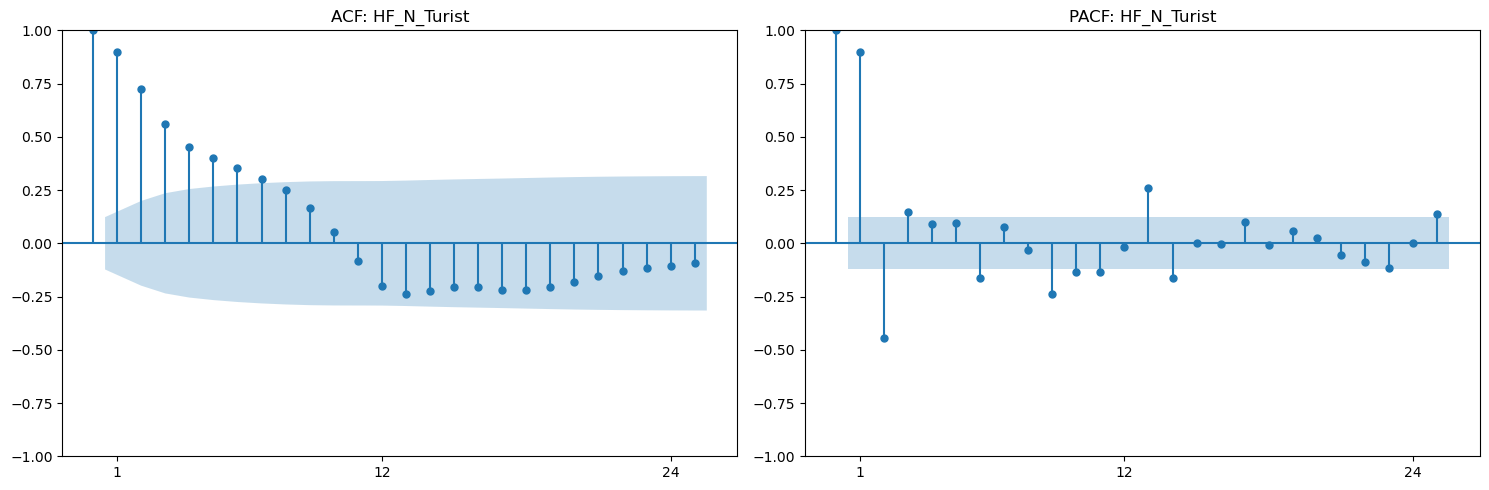

In [ ]:
# Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot ACF on the first subplot (axes[0])
plot_acf(hfti["Factor_1_KSmoother"].dropna(), ax=axes[0], title="ACF: HF_N_Turist")
axes[0].set_xticks([1, 12, 24]) 

# Plot PACF on the second subplot (axes[1])
# Default method for pacf is 'ywm'; depending on statsmodels version you might need to specify method='ywm' to avoid warnings
plot_pacf(hfti["Factor_1_KSmoother"].dropna(), ax=axes[1], title="PACF: HF_N_Turist", method='ywm')
axes[1].set_xticks([1, 12, 24]) 

# Adjust layout to prevent overlap and display the graphs
plt.tight_layout()
plt.show()


<Axes: title={'center': 'Difference of order 12 of the Common Factor (Kalman Filter)'}, xlabel='Time'>

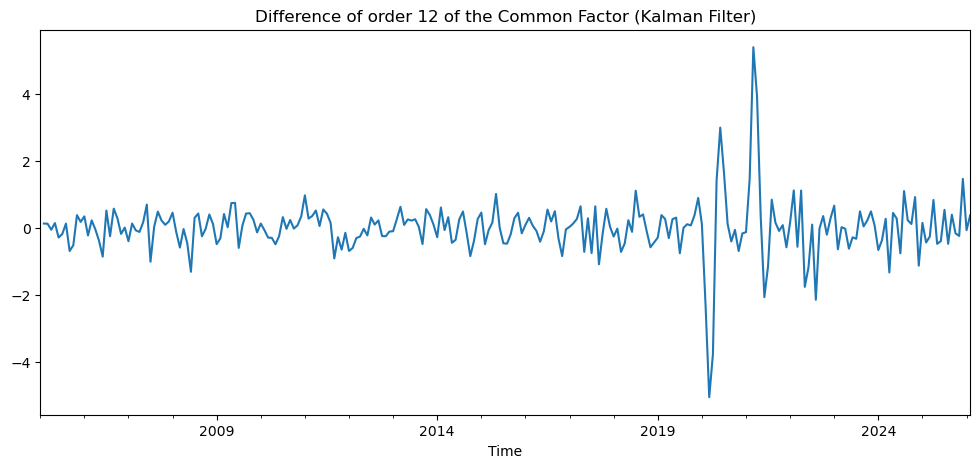

In [ ]:
# First diffence of the common factor
s= 12
hfti["Factor_1_KSmoother"].diff().plot(figsize=(12,5), title=f"Difference of order {s} of the Common Factor (Kalman Filter)")

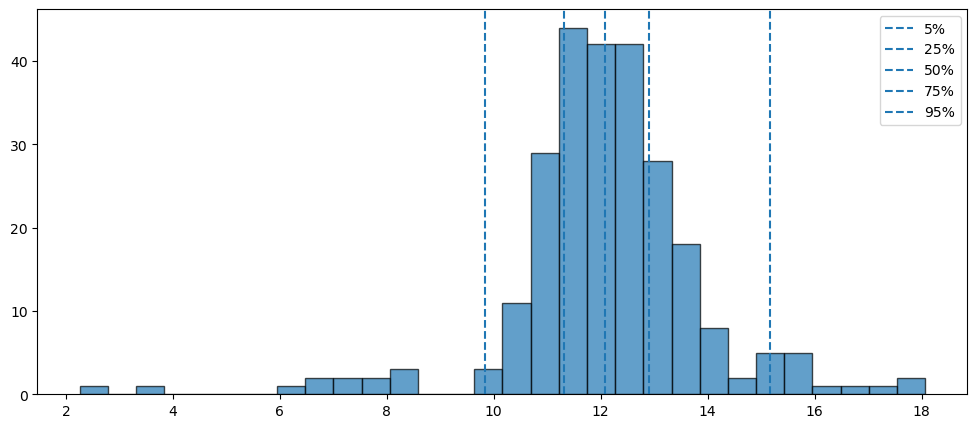

In [ ]:
# Histogram of the time series
fig, ax = plt.subplots(figsize = (12,5))
ax.hist(hfti["Factor_1_KSmoother"], bins=30, edgecolor='black', alpha=0.7)

for q, label in zip([0.05, 0.25, 0.50, 0.75, 0.95], ['5%','25%','50%','75%','95%']):
    ax.axvline(np.quantile(hfti["Factor_1_KSmoother"], q), linestyle='--', label=label)

ax.legend()
plt.show()

## Correlations

In [ ]:

# Import the risk indexes
monthly_gpr = pd.read_excel(r"data_gpr_monthly.xlsx", sheet_name="data")
epu = pd.read_csv("NEW_SPAIN_EPU_INDEX.csv", skiprows=1)
epu_YoY = epu["EPU_Spain"].diff(12).dropna()

# Lets put all the time series into a single dataframe and export it 
combined_df = pd.concat([turismo_residencia_12d, hfti['Factor_1_KSmoother'], monthly_gpr["GPRC_ESP"].diff(12), epu_YoY], axis=1)

# Align time series
start_date_kf = hfti['Factor_1_KSmoother'].first_valid_index()

# Combine and drop NAS
combined_df = combined_df.loc[start_date_kf:]


# Rename columns (optional, but recommended before exporting)
combined_df.reset_index(inplace=True)
combined_df.columns = ["Date","N_turistas_YoY", "HF_indicator","GPRC_ESP_YoY", "EPU_YoY"] 

# Export to CSV
combined_df.reset_index().to_csv("merged_series.csv", index= False)

# A cleaner looking pairplot with regression lines
sns.pairplot(combined_df, kind="reg", corner=False, plot_kws={'scatter_kws': {'alpha': 0.5}})

plt.show()

